# Setup and sanity check

Use this notebook first in Colab.

In [13]:
default_estimate = counts.get("1", 0) / 4000
print(f"Original PD: {pd_value:.4f}")
print(f"Estimated PD from quantum simulation: {default_estimate:.4f}")

Original PD: 0.0200
Estimated PD from quantum simulation: 0.0220


In [12]:
from src.quantum.circuit_builders import default_probability_circuit
from src.quantum.simulators import run_counts

pd_value = float(df.loc[0, "pd"])
print("Chosen loan:", df.loc[0, "loan_id"])
print("PD:", pd_value)

qc = default_probability_circuit(pd_value)
print(qc.draw())

counts = run_counts(qc, shots=4000)
print("Measurement counts:", counts)

Chosen loan: L1
PD: 0.02
     ┌─────────────┐┌─┐
  q: ┤ Ry(0.28379) ├┤M├
     └─────────────┘└╥┘
c: 1/════════════════╩═
                     0 
Measurement counts: {'1': 88, '0': 3912}


In [11]:
print(f"Odotettu tappio on noin {results['expected_loss']:.2f}.")
print(f"95 % skenaarioista tappio jää alle noin {results['var_95']:.2f}.")

Odotettu tappio on noin 10447.40.
95 % skenaarioista tappio jää alle noin 75000.00.


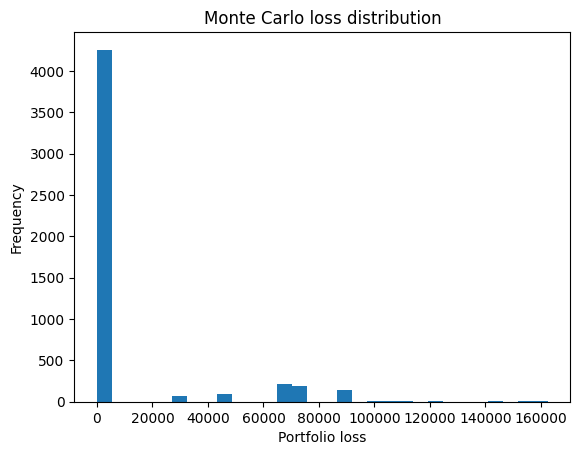

In [10]:
import matplotlib.pyplot as plt

plt.hist(results["losses"], bins=30)
plt.xlabel("Portfolio loss")
plt.ylabel("Frequency")
plt.title("Monte Carlo loss distribution")
plt.show()

In [9]:
from src.classical.monte_carlo_credit import run_credit_monte_carlo

results = run_credit_monte_carlo(df, n_sims=5000, seed=42)

print("Expected loss:", results["expected_loss"])
print("Std loss:", results["std_loss"])
print("VaR 95:", results["var_95"])

Expected loss: 10447.4
Std loss: 26521.03567434726
VaR 95: 75000.0


In [8]:
print("Rivejä:", len(df))
print("Sarakkeet:", list(df.columns))
print()
print(df.describe(include="all"))

Rivejä: 5
Sarakkeet: ['loan_id', 'segment', 'ead', 'pd', 'lgd', 'interest_margin']

       loan_id segment            ead        pd       lgd  interest_margin
count        5       5       5.000000  5.000000  5.000000         5.000000
unique       5       3            NaN       NaN       NaN              NaN
top         L1  retail            NaN       NaN       NaN              NaN
freq         1       2            NaN       NaN       NaN              NaN
mean       NaN     NaN  140000.000000  0.031000  0.450000         0.038000
std        NaN     NaN   66708.320321  0.014318  0.079057         0.010368
min        NaN     NaN   80000.000000  0.015000  0.350000         0.025000
25%        NaN     NaN  100000.000000  0.020000  0.400000         0.030000
50%        NaN     NaN  120000.000000  0.030000  0.450000         0.040000
75%        NaN     NaN  150000.000000  0.040000  0.500000         0.045000
max        NaN     NaN  250000.000000  0.050000  0.550000         0.050000


In [15]:
from src.business.credit_portfolio import load_credit_portfolio

df = load_credit_portfolio("/content/ai-quantum-learning-lab/data/demo_credit_portfolio.csv")
df

,loan_id,segment,ead,pd,lgd,interest_margin
0,L1,retail,100000,0.020,0.45,0.030
1,L2,sme,150000,0.040,0.50,0.040
2,L3,retail,80000,0.015,0.40,0.025
3,L4,corporate,250000,0.030,0.35,0.050
4,L5,sme,120000,0.050,0.55,0.045


In [4]:
!pip install -q openai pandas numpy matplotlib "qiskit[all]>=2.3.0" "qiskit-aer>=0.17.0"

In [5]:
!git clone https://github.com/harriryynanen/ai-quantum-learning-lab.git

fatal: destination path 'ai-quantum-learning-lab' already exists and is not an empty directory.


In [6]:
import sys
sys.path.append('/content/ai-quantum-learning-lab')
print('Repo path added.')

Repo path added.
